In [2]:
from icosphere import icosphere
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

from geo import adjacency, tectonics, helpers

#SEED = 18192601
SEED = 19960326
random.seed(SEED)
np.random.seed(SEED)

NU = 60
N_CONTINENTS = 19
MAX_CONVERGENT = 50
MIN_DIVERGENT = -30

In [3]:
vertices, faces = icosphere(NU)
print(f'nu={NU},vertices={vertices.shape}, faces={faces.shape}')

nu=60,vertices=(36002, 3), faces=(72000, 3)


In [ ]:
def build_icosphere_ridge_points_interface(faces):
    i_ridge_points = {}
    for idx, (v1, v2, v3) in enumerate(faces):
        keys = [tuple(sorted([v1, v2])), tuple(sorted([v1, v3])), tuple(sorted([v3, v2]))]
        for key in keys:
            if key in i_ridge_points:
                i_ridge_points[key].append(idx)
            else:
                i_ridge_points[key] = [idx]

    return i_ridge_points

def build_icosphere_points_interface(faces, vertices):
    i_points = np.zeros(shape=faces.shape)
    for idx, face in enumerate(faces):
        i_points[idx] = vertices[face].mean(axis=0)

    return i_points

def random_tangent_vector(p):
    r = np.random.randn(3)
    r = r - np.dot(r, p) * p
    return r / np.linalg.norm(r)

In [4]:
i_ridge_points = build_icosphere_ridge_points_interface(faces)
i_points = build_icosphere_points_interface(faces, vertices)
adjacency_graph = adjacency.build_adjacency(faces, i_ridge_points.values())

In [ ]:
continent_labels = tectonics.classify_continents_v2(adjacency_graph, N_CONTINENTS, noise=.66)
centroids = {label: i_points[continent_labels == label].mean(axis=0) for label in np.unique(continent_labels)}

In [6]:
continent_vectors = {label: random_tangent_vector(centroid) for label, centroid in centroids.items()}
landmass_adjacency = adjacency.build_landmass_adjacency(faces, i_ridge_points.values(), continent_labels)

In [7]:
from types import SimpleNamespace

i_vor = SimpleNamespace(ridge_vertices=np.ones((len(i_ridge_points), 1)), ridge_points=i_ridge_points.values())

In [ ]:
def propagate_elevations(elevations, continent_labels, adjacency_by_landmass, decay=0.25, mode=None):
    new_elevations = elevations.copy()
    elevated_cells_by_landmass = {label: [idx for idx, tag in enumerate(continent_labels) if tag == label and elevations[idx] != 0] for label in np.unique(continent_labels)}

    dependencies, wave = tectonics.compute_dependencies(elevated_cells_by_landmass, adjacency_by_landmass)

    for idx, sources in dependencies.items():
        if not sources:
            continue

        n = len(sources)
        avg = sum(new_elevations[sources]) / n
        new_elevations[idx] = avg * decay ** (wave[idx] / n ** decay)

    if mode == 'debug':
        return new_elevations, dependencies, wave
    
    return new_elevations

In [149]:
elevations = tectonics.infer_elevation(i_points, i_vor, continent_labels, continent_vectors)
pro_elevations, dep, waves = propagate_elevations(elevations, continent_labels, landmass_adjacency, decay=.96, k=.75, mode='debug')
_, sea_level = tectonics.apply_sea_level(pro_elevations, 75)

In [ ]:
i = 70991
n = len(dep[i])
print(sum(pro_elevations[dep[i]]) / n * .96 ** (waves[i] / n ** .96))
print(pro_elevations[i])



0.0007321757022249606
0.0006391505667336924


In [106]:
.96 ** (10/ 1 **.96)

0.6648326359915008

In [ ]:
waves_array = np.array([waves[idx] for idx in sorted(list(waves.keys()))])
dep_count_array = np.array([len(dep[idx]) for idx in sorted(list(dep.keys()))])

In [111]:
np.where(dep_count_array == 1)

(array([    0,     1,     2, ..., 71993, 71996, 71997], shape=(46911,)),)

In [118]:
print(adjacency_graph[71993])
print(landmass_adjacency[71993])
print(dep[71993])

{71992, 50409, 71994}
{71992, 50409, 71994}
[50409]


In [124]:
print(dep[71994])
print(waves[71994])
print(waves_array[dep[71994]])


[71993, 71995]
9
[8 8]


In [32]:
x = elevations[elevations != 0]
print(np.quantile(x, [.1, .2, .6, .9, .99]))
print(x.max())
print(x.min())
print(x.mean())

[-7.57070251 -5.73710419  3.7432294  32.68334034 65.36668068]
66.73148470467272
-16.325219908010542
6.606549065016183


In [31]:
x = pro_elevations
print(np.quantile(x, [.1, .2, .6, .9, .99]))
print(x.max())
print(x.min())
print(x.mean())

[-2.28907123e+00 -5.62145232e-01  7.50327112e-07  7.36625531e+00
  3.26728634e+01]
66.73148470467272
-16.325219908010542
1.6441856625680822


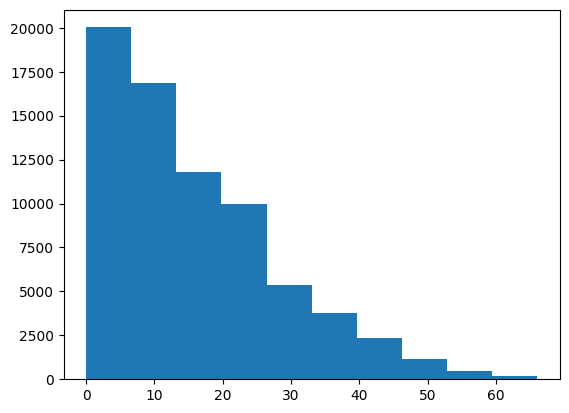

In [16]:
fig, ax = plt.subplots()
ax.hist(waves.values())
plt.show()

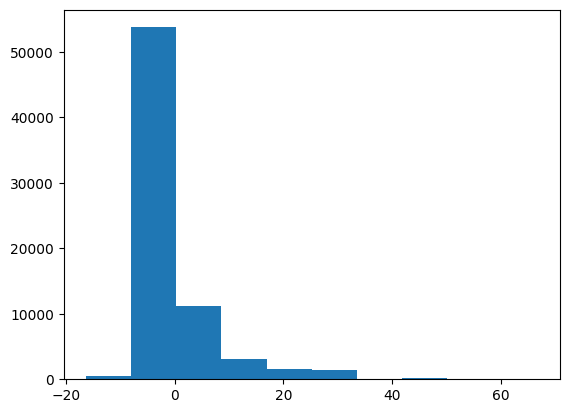

In [26]:
fig, ax = plt.subplots()
ax.hist(pro_elevations)
plt.show()

In [150]:
def build_terrain_cm(elevations, sea_level):
    min_e = elevations.min()
    max_e = elevations.max()
    sea_level_norm = (sea_level - min_e) / (max_e - min_e)

    return [
        [0, 'darkblue'],
        [sea_level_norm * .5, 'steelblue'],
        [sea_level_norm, 'lightblue'],
        [sea_level_norm + .001, 'darkgreen'],
        [sea_level_norm + (1 - sea_level_norm) * .5, 'brown'],
        [1.0, 'white']
    ], (elevations - min_e) / (max_e - min_e)

colorscale, intensity = build_terrain_cm(pro_elevations, sea_level)

In [136]:
x, y, z = vertices.T
i, j, k = faces.T
#intensity = np.array(pro_elevations)

In [152]:
import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Mesh3d(
        x=x, y=y, z=z,
        i=i, j=j, k=k,
        intensity=intensity,
        intensitymode='cell',
        colorscale=colorscale,
        showscale=True,
        flatshading=True
    )
])

fig.show()
